# 💰 Claim Severity Prediction
**Objectif :** Prédire `MT_EVALUATION` (coût d'un sinistre) **au moment de sa déclaration**, avant expertise complète.

**Applications métier :**
- 📊 **Provisionnement automatique** — réserver le bon montant dès J+0
- 🔁 **Réassurance** — déclencher les traités XL si sévérité prédite > seuil
- 💲 **Pricing** — alimenter les modèles de tarification avec la sinistralité réelle
- ⚡ **Priorisation** — traiter en urgence les dossiers à fort coût prévu

**Modèles :**
| Modèle | Usage |
|---|---|
| **XGBoost / LightGBM** | Prédiction principale (robuste, rapide) |
| **Tweedie Regression** | Distribution de pertes (standard actuariel) |
| **Quantile Regression** | Intervalles de confiance p10/p50/p90 |
| **Ensemble** | Combinaison pondérée pour production |

---

## 0. Setup

In [23]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import TweedieRegressor, QuantileRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.inspection import permutation_importance

import xgboost as xgb
import lightgbm as lgb
import shap

plt.rcParams['figure.figsize'] = (13, 5)
sns.set_style('whitegrid')
np.random.seed(42)

print('✅ Setup complet')

✅ Setup complet


## 1. Chargement des Données

In [24]:
def load(filename, date_cols=None):
    # Use absolute path to data directory for robustness
    import os
    base_dir = r'C:\Users\LENOVO\Desktop\PFE_\maghrebia\data\raw'
    path = os.path.join(base_dir, filename)
    # Remove unsupported 'low_memory' for engine='python'
    df = pd.read_csv(path, sep=None, engine='python')
    df.columns = df.columns.str.strip().str.lstrip('\ufeff')
    if date_cols:
        for c in date_cols:
            if c in df.columns:
                df[c] = pd.to_datetime(df[c], errors='coerce')
    return df

sinistre   = load('DWH_FACT_SINISTRE.csv',   ['DATE_SURVENANCE', 'DATE_DECLARATION'])
emission   = load('DWH_FACT_EMISSION.csv',   ['DATE_EMISSION', 'DATE_EFFET', 'DATE_ECHEANCE'])
impaye     = load('DWH_FACT_IMPAYE.csv',     ['DATE_EMISSION'])
annulation = load('DWH_FACT_ANNULATION.csv', ['DATE_ANNULATION'])
vehicule   = load('DIM_VEHICULE.csv',        ['DATE_MEC'])
client     = load('DIM_CLIENT.csv',          ['DATE_NAISSANCE'])
police_dim = load('DIM_POLICE.csv',          ['DATE_EFFET', 'DATE_ECHEANCE'])

print(f'Sinistres  : {len(sinistre):,}')
print(f'Emissions  : {len(emission):,}')
print(f'Véhicules  : {len(vehicule):,}')
print(f'Clients    : {len(client):,}')
print(f'Polices    : {len(police_dim):,}')

Sinistres  : 8,000
Emissions  : 65,000
Véhicules  : 20,000
Clients    : 30,000
Polices    : 30,000


## 2. Feature Engineering

On ne doit utiliser que des features **disponibles au moment de la déclaration** (pas de data leakage).

```
✅ Disponible à la déclaration     ❌ Disponible seulement après
────────────────────────────────   ─────────────────────────────
Nature sinistre                    MT_PAYE (règlement final)
Date survenance                    ETAT_SINISTRE final
Véhicule (marque, âge, valeur)     Expertise détaillée
Historique client
Bonus/malus
Branche, produit
```

In [25]:
df = sinistre.copy()

# ══════════════════════════════════════════════════════════════════════
# BLOC A — Features du sinistre lui-même
# ══════════════════════════════════════════════════════════════════════
df['DELAI_DECLARATION']  = (df['DATE_DECLARATION'] - df['DATE_SURVENANCE']).dt.days.clip(0, 365)
df['MOIS_SURVENANCE']    = df['DATE_SURVENANCE'].dt.month
df['TRIMESTRE']          = df['DATE_SURVENANCE'].dt.quarter
df['JOUR_SEMAINE']       = df['DATE_SURVENANCE'].dt.dayofweek
df['FLAG_WEEKEND']       = (df['JOUR_SEMAINE'] >= 5).astype(int)
df['ANNEE_SURVENANCE']   = df['DATE_SURVENANCE'].dt.year

# ══════════════════════════════════════════════════════════════════════
# BLOC B — Features véhicule
# ══════════════════════════════════════════════════════════════════════
veh = vehicule[[
    'ID_VEHICULE', 'MARQUE', 'PUISSANCE', 'GENRE_VEHICULE',
    'TYPE_VEHICULE', 'NB_PLACE', 'DATE_MEC',
    'VALEUR_A_NEUF', 'VALEUR_ACTUELLE', 'CHARGE_UTILE', 'POIDS_TOTAL', 'CODE_USAGE'
]].copy()

# Âge véhicule au moment du sinistre
df = df.merge(veh, on='ID_VEHICULE', how='left')
df['AGE_VEHICULE'] = (
    (df['DATE_SURVENANCE'] - df['DATE_MEC']).dt.days / 365.25
).clip(0, 50)

# Taux de dépréciation
df['TAUX_DEPRECIATION'] = np.where(
    (df['VALEUR_A_NEUF'] > 0) & df['VALEUR_A_NEUF'].notna(),
    df['VALEUR_ACTUELLE'] / df['VALEUR_A_NEUF'],
    np.nan
)
# Winsorize valeurs aberrantes
df['VALEUR_A_NEUF']     = df['VALEUR_A_NEUF'].clip(0, df['VALEUR_A_NEUF'].quantile(0.99))
df['VALEUR_ACTUELLE']   = df['VALEUR_ACTUELLE'].clip(0, df['VALEUR_ACTUELLE'].quantile(0.99))

# ══════════════════════════════════════════════════════════════════════
# BLOC C — Features client
# ══════════════════════════════════════════════════════════════════════
cli = client[['ID_CLIENT', 'TYPE_PERSONNE', 'SEXE', 'DATE_NAISSANCE', 'NATP']].copy()
df = df.merge(cli, on='ID_CLIENT', how='left')

df['AGE_CLIENT'] = (
    (df['DATE_SURVENANCE'] - df['DATE_NAISSANCE']).dt.days / 365.25
).clip(18, 90)

# Historique sinistres client (avant la date de survenance — pas de leakage)
df_sorted = df.sort_values('DATE_SURVENANCE')
df_sorted['CLIENT_NB_SIN_HIST'] = (
    df_sorted.groupby('ID_CLIENT').cumcount()  # nb sinistres précédents
)
df['CLIENT_NB_SIN_HIST'] = df_sorted['CLIENT_NB_SIN_HIST']

# Montant moyen des sinistres précédents du client
def rolling_mean_exclude_current(group):
    return group['MT_EVALUATION'].shift(1).expanding().mean()

df_sorted['CLIENT_MT_SIN_MOY_HIST'] = (
    df_sorted.groupby('ID_CLIENT', group_keys=False)
    .apply(rolling_mean_exclude_current)
)
df['CLIENT_MT_SIN_MOY_HIST'] = df_sorted['CLIENT_MT_SIN_MOY_HIST'].fillna(0)

# ══════════════════════════════════════════════════════════════════════
# BLOC D — Features police
# ══════════════════════════════════════════════════════════════════════
pol = police_dim[[
    'ID_POLICE', 'BONUS_MALUS', 'TYPE_POLICE', 'DUREE', 'PERIODICITE',
    'DATE_EFFET', 'DATE_ECHEANCE', 'SITUATION'
]].copy()
df = df.merge(pol, on='ID_POLICE', how='left')

df['JOURS_DEPUIS_EFFET']   = (df['DATE_SURVENANCE'] - df['DATE_EFFET']).dt.days.clip(0)
df['JOURS_AVANT_ECHEANCE'] = (df['DATE_ECHEANCE'] - df['DATE_SURVENANCE']).dt.days.clip(0)
df['FLAG_SIN_PRECOCE']     = (df['JOURS_DEPUIS_EFFET'] < 30).astype(int)

# ══════════════════════════════════════════════════════════════════════
# BLOC E — Features emission (primes payées = proxy de valeur assurée)
# ══════════════════════════════════════════════════════════════════════
pol_em = emission.groupby('ID_POLICE').agg(
    PRIME_MOY=('MT_PNET', 'mean'),
    PRIME_MAX=('MT_PNET', 'max'),
    NB_QUITTANCES=('NUM_QUITTANCE', 'count'),
    BONUS_MALUS_EM=('BONUS_MALUS', 'mean'),
).reset_index()
df = df.merge(pol_em, on='ID_POLICE', how='left')

# ══════════════════════════════════════════════════════════════════════
# BLOC F — Features impayés (risque client)
# ══════════════════════════════════════════════════════════════════════
pol_imp = impaye.groupby('ID_POLICE').agg(
    NB_IMPAYES=('NUM_QUITTANCE', 'count'),
    MT_IMPAYE_TOTAL=('MT_PTT', 'sum'),
).reset_index()
df = df.merge(pol_imp, on='ID_POLICE', how='left')
df[['NB_IMPAYES','MT_IMPAYE_TOTAL']] = df[['NB_IMPAYES','MT_IMPAYE_TOTAL']].fillna(0)

print(f'Dataset enrichi : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print(f'Valeurs manquantes (top 10):\n{df.isnull().sum().sort_values(ascending=False).head(10)}')

Dataset enrichi : 8000 lignes × 56 colonnes
Valeurs manquantes (top 10):
BONUS_MALUS_EM       3989
AGE_VEHICULE         3158
TAUX_DEPRECIATION    3113
DATE_MEC             3093
VALEUR_ACTUELLE      3006
VALEUR_A_NEUF        2997
CHARGE_UTILE         2926
BONUS_MALUS          2926
CODE_USAGE           2926
POIDS_TOTAL          2926
dtype: int64


## 3. Analyse de la Target — MT_EVALUATION

In [26]:
fig = make_subplots(rows=2, cols=3, subplot_titles=[
    'Distribution MT_EVALUATION (brut)',
    'Distribution log(MT_EVALUATION)',
    'Sévérité par Nature de Sinistre',
    'Sévérité par Branche',
    'Sévérité vs Âge Véhicule',
    'Sévérité vs Bonus/Malus'
])

# Distribution brute
fig.add_trace(go.Histogram(x=df['MT_EVALUATION'].clip(0, 20000), nbinsx=80,
                            marker_color='steelblue', name='Brut'), row=1, col=1)

# Log-normale
fig.add_trace(go.Histogram(x=np.log1p(df['MT_EVALUATION']), nbinsx=60,
                            marker_color='darkorange', name='Log'), row=1, col=2)

# Par nature
nature_med = df.groupby('NATURE_SINISTRE')['MT_EVALUATION'].median().sort_values()
fig.add_trace(go.Bar(x=nature_med.values, y=nature_med.index,
                     orientation='h', marker_color='teal', name='Par Nature'), row=1, col=3)

# Par branche
branch_med = df.groupby('BRANCHE')['MT_EVALUATION'].median().sort_values()
fig.add_trace(go.Bar(x=branch_med.values, y=branch_med.index,
                     orientation='h', marker_color='purple', name='Par Branche'), row=2, col=1)

# Sévérité vs âge véhicule
fig.add_trace(go.Scatter(x=df['AGE_VEHICULE'].dropna(),
                          y=df.loc[df['AGE_VEHICULE'].notna(), 'MT_EVALUATION'].clip(0, 30000),
                          mode='markers', marker=dict(size=3, opacity=0.3, color='crimson'),
                          name='Age vs Sév'), row=2, col=2)

# Bonus/Malus
bm_med = df.groupby('BONUS_MALUS')['MT_EVALUATION'].median().reset_index().dropna()
fig.add_trace(go.Bar(x=bm_med['BONUS_MALUS'].astype(str), y=bm_med['MT_EVALUATION'],
                     marker_color='gold', name='Bonus/Malus'), row=2, col=3)

fig.update_layout(height=650, title_text='📊 Analyse de la Target — MT_EVALUATION',
                  showlegend=False)
fig.show()

print(f'Skewness brut   : {df["MT_EVALUATION"].skew():.2f}')
print(f'Skewness log+1  : {np.log1p(df["MT_EVALUATION"]).skew():.2f}')
print('\n→ On va entraîner les modèles sur log(MT_EVALUATION) et back-transformer les prédictions')

Skewness brut   : 16.28
Skewness log+1  : 0.00

→ On va entraîner les modèles sur log(MT_EVALUATION) et back-transformer les prédictions


In [27]:
# Statistiques par nature — table de référence actuarielle
severity_table = df.groupby('NATURE_SINISTRE')['MT_EVALUATION'].agg([
    'count',
    ('Médiane', 'median'),
    ('Moyenne', 'mean'),
    ('Écart-type', 'std'),
    ('p75', lambda x: x.quantile(0.75)),
    ('p90', lambda x: x.quantile(0.90)),
    ('p95', lambda x: x.quantile(0.95)),
    ('p99', lambda x: x.quantile(0.99)),
    ('Max', 'max'),
]).round(0)

display(severity_table.style
    .background_gradient(subset=['Moyenne','p90','p99'], cmap='YlOrRd')
    .format('{:,.0f}', subset=severity_table.columns[1:]))

,count,Médiane,Moyenne,Écart-type,p75,p90,p95,p99,Max
NATURE_SINISTRE,,,,,,,,,
Bris de Glace,1005,"1,082","1,682","1,883","2,121","3,759","5,073","9,164","16,978"
Corporel,468,"1,050","1,801","2,239","2,045","4,307","6,236","11,839","15,974"
Dentaire,292,94,104,52,133,170,205,264,379
Dégât des eaux,592,"2,904","7,833","16,352","7,531","18,270","31,367","75,046","207,794"
Hospitalisation,130,"1,886","2,691","2,656","3,155","5,778","7,901","13,610","17,084"
Incendie,640,"3,023","8,991","23,148","7,642","18,303","35,800","96,174","358,812"
Maladie Courante,545,88,101,54,123,177,204,280,369
Matériel,3035,"1,115","1,812","2,388","2,124","4,031","5,759","10,966","38,733"
Pharmacie,429,93,107,58,136,185,216,286,398


## 4. Préparation du Dataset Final

In [28]:
# ── Encodage des catégorielles ─────────────────────────────────────────────
cat_cols = [
    'NATURE_SINISTRE', 'BRANCHE', 'MARQUE', 'GENRE_VEHICULE',
    'TYPE_VEHICULE', 'TYPE_PERSONNE', 'SEXE', 'TYPE_POLICE', 'DUREE', 'PERIODICITE'
]
cat_cols = [c for c in cat_cols if c in df.columns]

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[f'{col}_ENC'] = le.fit_transform(df[col].astype(str).fillna('INCONNU'))
    encoders[col] = le

# ── Sélection des features ─────────────────────────────────────────────────
FEATURE_COLS = [
    # Sinistre
    'RESPONSABILITE', 'DELAI_DECLARATION',
    'MOIS_SURVENANCE', 'TRIMESTRE', 'JOUR_SEMAINE', 'FLAG_WEEKEND', 'ANNEE_SURVENANCE',
    'NATURE_SINISTRE_ENC',
    # Véhicule
    'PUISSANCE', 'NB_PLACE', 'AGE_VEHICULE',
    'VALEUR_A_NEUF', 'VALEUR_ACTUELLE', 'TAUX_DEPRECIATION',
    'CHARGE_UTILE', 'POIDS_TOTAL', 'CODE_USAGE',
    'GENRE_VEHICULE_ENC', 'TYPE_VEHICULE_ENC', 'MARQUE_ENC',
    # Client
    'AGE_CLIENT', 'TYPE_PERSONNE_ENC', 'SEXE_ENC',
    'CLIENT_NB_SIN_HIST', 'CLIENT_MT_SIN_MOY_HIST',
    # Police
    'BONUS_MALUS', 'JOURS_DEPUIS_EFFET', 'JOURS_AVANT_ECHEANCE',
    'FLAG_SIN_PRECOCE', 'TYPE_POLICE_ENC',
    # Emission
    'PRIME_MOY', 'PRIME_MAX', 'NB_QUITTANCES', 'BONUS_MALUS_EM',
    # Risque
    'NB_IMPAYES', 'MT_IMPAYE_TOTAL',
    # Branche
    'BRANCHE_ENC', 'ID_BRANCHE',
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

TARGET = 'MT_EVALUATION'
TARGET_LOG = 'LOG_MT_EVALUATION'

# Filtrer les lignes avec target valide
df_model = df[df[TARGET] > 0].copy()
df_model[TARGET_LOG] = np.log1p(df_model[TARGET])

X = df_model[FEATURE_COLS].fillna(df_model[FEATURE_COLS].median())
y_log = df_model[TARGET_LOG]
y_raw = df_model[TARGET]

# Split temporel (respecte l'ordre chronologique)
df_model_sorted = df_model.sort_values('DATE_SURVENANCE')
split_idx = int(len(df_model_sorted) * 0.80)

train_idx = df_model_sorted.index[:split_idx]
test_idx  = df_model_sorted.index[split_idx:]

X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train_log, y_test_log = y_log.loc[train_idx], y_log.loc[test_idx]
y_train_raw, y_test_raw = y_raw.loc[train_idx], y_raw.loc[test_idx]

print(f'Train : {len(X_train):,} sinistres')
print(f'Test  : {len(X_test):,} sinistres')
print(f'Features : {len(FEATURE_COLS)}')

Train : 6,400 sinistres
Test  : 1,600 sinistres
Features : 38


## 5. Modèle 1 — XGBoost

In [29]:
def eval_model(y_true_log, y_pred_log, name):
    """Évalue sur l'échelle log ET l'échelle originale."""
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    
    # Gini-like metric : corrélation rang
    gini = np.corrcoef(y_true, y_pred)[0, 1]
    
    # Biais moyen (sur- ou sous-estimation)
    biais = (y_pred.mean() - y_true.mean()) / y_true.mean() * 100
    
    print(f'  {name:25s} MAE={mae:>8,.0f} TND | RMSE={rmse:>9,.0f} | MAPE={mape:5.1f}% | Gini={gini:.3f} | Biais={biais:+.1f}%')
    return {'Modèle': name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'Gini': gini, 'Biais%': biais}

results = []

# ── XGBoost ────────────────────────────────────────────────────────────────
xgb_model = xgb.XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='reg:squarederror',
    early_stopping_rounds=30,
    eval_metric='rmse',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(
    X_train, y_train_log,
    eval_set=[(X_test, y_test_log)],
    verbose=False
)

pred_xgb = xgb_model.predict(X_test)
results.append(eval_model(y_test_log, pred_xgb, 'XGBoost'))

print(f'  Best iteration : {xgb_model.best_iteration}')

  XGBoost                   MAE=   2,055 TND | RMSE=    7,265 | MAPE=119.6% | Gini=0.320 | Biais=-56.0%
  Best iteration : 105


## 6. Modèle 2 — LightGBM

In [30]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=10,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='regression',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_model.fit(
    X_train, y_train_log,
    eval_set=[(X_test, y_test_log)],
    callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)]
)

pred_lgb = lgb_model.predict(X_test)
results.append(eval_model(y_test_log, pred_lgb, 'LightGBM'))

  LightGBM                  MAE=   2,059 TND | RMSE=    7,243 | MAPE=119.1% | Gini=0.329 | Biais=-55.8%


## 7. Modèle 3 — Tweedie Regression (standard actuariel)
> La distribution de Tweedie est spécialement conçue pour les pertes d'assurance : elle gère les queues épaisses et les distributions asymétriques.

In [31]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# power=1.5 : entre Poisson (1) et Gamma (2) — adapté aux sinistres auto
tweedie = TweedieRegressor(power=1.5, alpha=0.1, max_iter=1000)
tweedie.fit(X_train_s, y_train_raw)   # Tweedie sur l'échelle brute

pred_tweedie = tweedie.predict(X_test_s)
pred_tweedie_log = np.log1p(np.clip(pred_tweedie, 0, None))
results.append(eval_model(y_test_log, pred_tweedie_log, 'Tweedie (p=1.5)'))

  Tweedie (p=1.5)           MAE=   2,752 TND | RMSE=    7,120 | MAPE=539.7% | Gini=0.225 | Biais=+5.6%


## 8. Modèle 4 — Quantile Regression
> Prédit non pas la valeur moyenne mais des **percentiles** → donne une fourchette de prévision pour le provisionnement.

In [32]:
quantile_models = {}
quantile_preds  = {}

# On utilise LightGBM en mode quantile (plus performant que sklearn QuantileRegressor)
for q in [0.10, 0.50, 0.90]:
    q_model = lgb.LGBMRegressor(
        objective='quantile',
        alpha=q,
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    q_model.fit(X_train, y_train_log,
                callbacks=[lgb.log_evaluation(-1)])
    quantile_models[q] = q_model
    quantile_preds[q]  = np.expm1(q_model.predict(X_test))
    print(f'  Quantile p{int(q*100):02d} — entraîné')

# Couverture de l'intervalle [p10, p90]
in_interval = (
    (np.expm1(y_test_log.values) >= quantile_preds[0.10]) &
    (np.expm1(y_test_log.values) <= quantile_preds[0.90])
).mean()
print(f'\nCouverture intervalle [p10, p90] : {in_interval*100:.1f}% (cible : 80%)')

  Quantile p10 — entraîné
  Quantile p50 — entraîné
  Quantile p90 — entraîné

Couverture intervalle [p10, p90] : 69.8% (cible : 80%)


## 9. Ensemble — Combinaison Pondérée

In [33]:
# Poids basés sur l'inverse du MAPE
mapes_dict = {r['Modèle']: r['MAPE'] for r in results if r['Modèle'] in ['XGBoost','LightGBM']}
inv_mapes = {m: 1/v for m, v in mapes_dict.items()}
total_w = sum(inv_mapes.values())
w_xgb = inv_mapes.get('XGBoost', 1) / total_w
w_lgb = inv_mapes.get('LightGBM', 1) / total_w

pred_ensemble_log = w_xgb * pred_xgb + w_lgb * pred_lgb
results.append(eval_model(y_test_log, pred_ensemble_log, f'Ensemble (XGB+LGB)'))

print(f'\nPoids : XGBoost={w_xgb:.1%} | LightGBM={w_lgb:.1%}')

  Ensemble (XGB+LGB)        MAE=   2,055 TND | RMSE=    7,256 | MAPE=118.9% | Gini=0.330 | Biais=-56.1%

Poids : XGBoost=49.9% | LightGBM=50.1%


## 10. Tableau de Bord des Performances

,MAE,RMSE,MAPE,Gini,Biais%
Modèle,,,,,
XGBoost,"2,055","7,265",119.6%,0.320,-56.0%
LightGBM,"2,059","7,243",119.1%,0.329,-55.8%
Tweedie (p=1.5),"2,752","7,120",539.7%,0.225,+5.6%
Ensemble (XGB+LGB),"2,055","7,256",118.9%,0.330,-56.1%


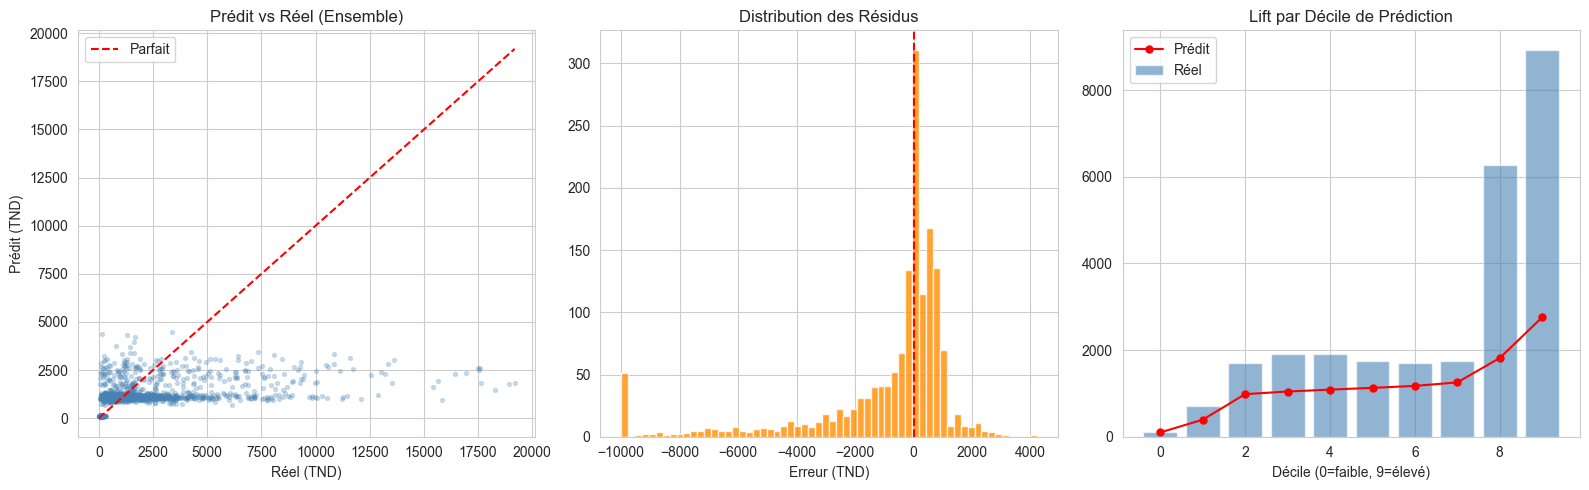

In [34]:
results_df = pd.DataFrame(results).set_index('Modèle')
display(
    results_df.style
    .highlight_min(subset=['MAE','RMSE','MAPE'], color='#c8f7c5')
    .highlight_max(subset=['Gini'], color='#c8f7c5')
    .format({'MAE': '{:,.0f}', 'RMSE': '{:,.0f}', 'MAPE': '{:.1f}%',
             'Gini': '{:.3f}', 'Biais%': '{:+.1f}%'})
)

# Visualisation prédit vs réel
y_true_plot = np.expm1(y_test_log.values)
y_pred_plot = np.expm1(pred_ensemble_log)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Scatter prédit vs réel
mask = y_true_plot < 20000
axes[0].scatter(y_true_plot[mask], y_pred_plot[mask], alpha=0.25, s=8, color='steelblue')
lim = max(y_true_plot[mask].max(), y_pred_plot[mask].max())
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Parfait')
axes[0].set_xlabel('Réel (TND)'); axes[0].set_ylabel('Prédit (TND)')
axes[0].set_title('Prédit vs Réel (Ensemble)')
axes[0].legend()

# Résidus
residus = y_pred_plot - y_true_plot
axes[1].hist(residus.clip(-10000, 10000), bins=60, color='darkorange', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Distribution des Résidus')
axes[1].set_xlabel('Erreur (TND)')

# Lift chart : top 20% prédit vs réel
lift_df = pd.DataFrame({'true': y_true_plot, 'pred': y_pred_plot})
lift_df['decile'] = pd.qcut(lift_df['pred'], 10, labels=False)
lift = lift_df.groupby('decile').agg(mean_true=('true','mean'), mean_pred=('pred','mean'))
axes[2].bar(lift.index, lift['mean_true'], alpha=0.6, label='Réel', color='steelblue')
axes[2].plot(lift.index, lift['mean_pred'], 'ro-', label='Prédit', markersize=5)
axes[2].set_title('Lift par Décile de Prédiction')
axes[2].set_xlabel('Décile (0=faible, 9=élevé)')
axes[2].legend()

plt.tight_layout(); plt.show()

## 11. Explainabilité SHAP

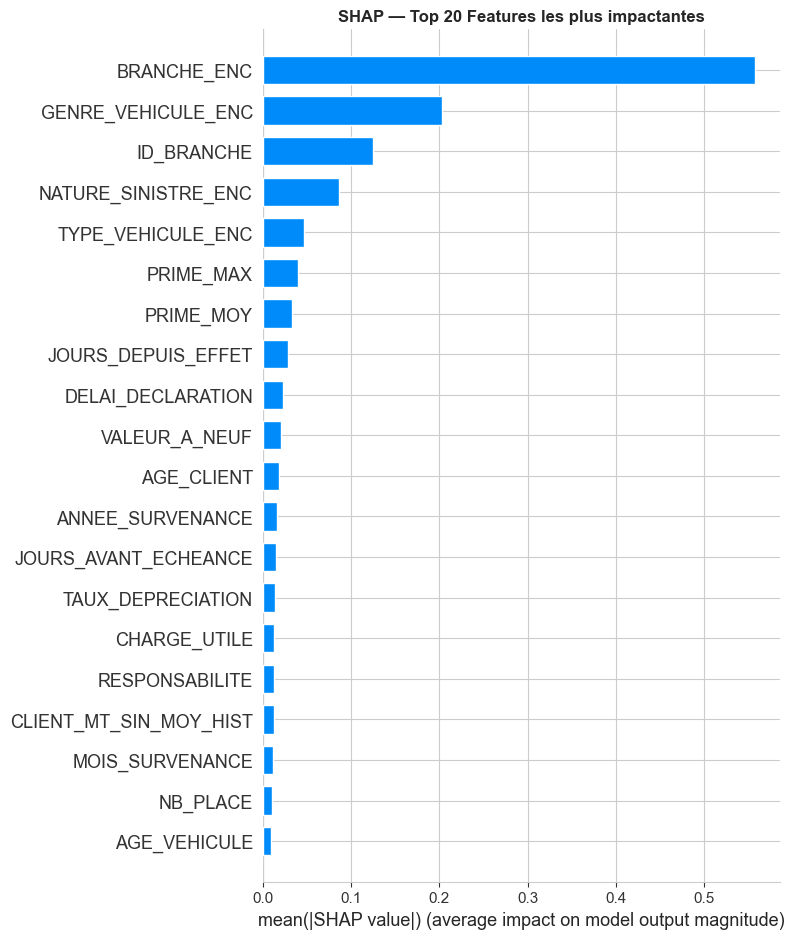

In [35]:
# SHAP sur LightGBM (plus rapide)
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test)

# Bar plot — importance globale
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, feature_names=FEATURE_COLS,
                  plot_type='bar', show=False, max_display=20)
plt.title('SHAP — Top 20 Features les plus impactantes', fontweight='bold')
plt.tight_layout(); plt.show()

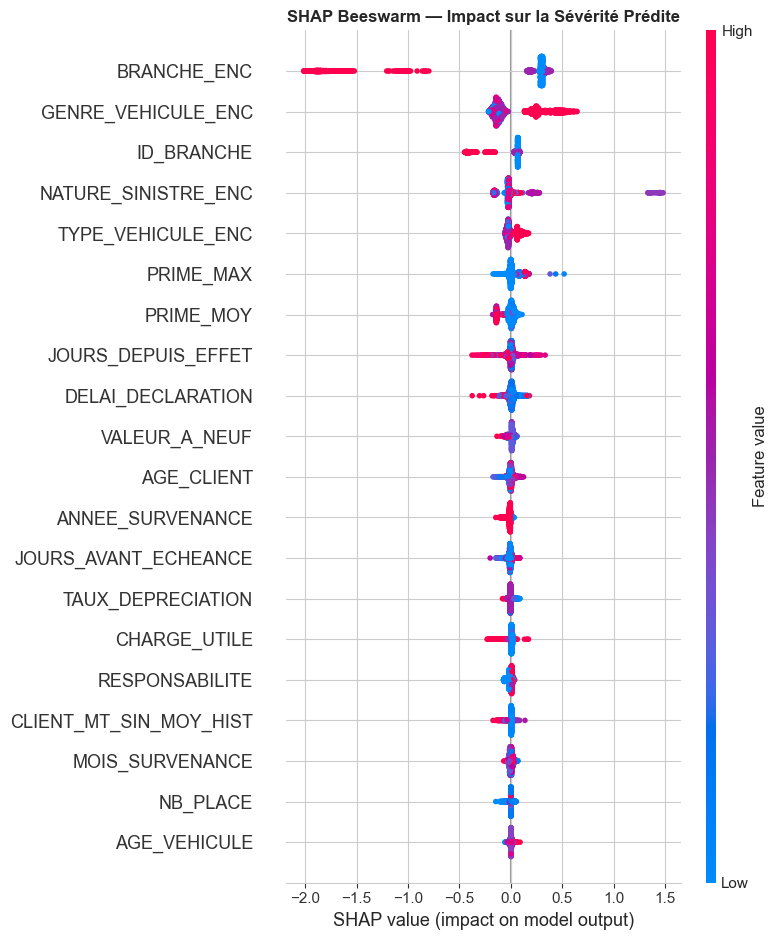

In [36]:
# Beeswarm — direction d'impact
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, feature_names=FEATURE_COLS,
                  show=False, max_display=20)
plt.title('SHAP Beeswarm — Impact sur la Sévérité Prédite', fontweight='bold')
plt.tight_layout(); plt.show()

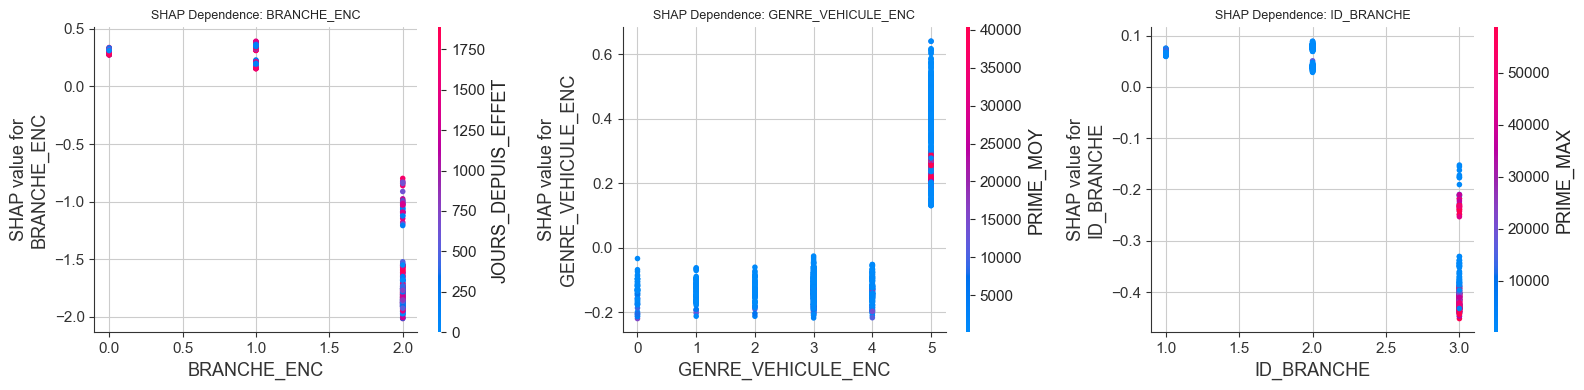

In [37]:
# Dependence plots — les 3 features les plus importantes
shap_imp = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURE_COLS
).sort_values(ascending=False)

top3 = shap_imp.index[:3].tolist()
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, feat in zip(axes, top3):
    shap.dependence_plot(feat, shap_values, X_test,
                         feature_names=FEATURE_COLS, ax=ax, show=False)
    ax.set_title(f'SHAP Dependence: {feat}', fontsize=9)
plt.tight_layout(); plt.show()

## 12. Analyse de la Sévérité par Segment

In [38]:
# Ajouter les prédictions au dataframe de test
df_test_results = df_model.loc[test_idx].copy()
df_test_results['PRED_MEDIAN']  = np.expm1(pred_ensemble_log)
df_test_results['PRED_P10']     = quantile_preds[0.10]
df_test_results['PRED_P90']     = quantile_preds[0.90]
df_test_results['PRED_RANGE']   = df_test_results['PRED_P90'] - df_test_results['PRED_P10']
df_test_results['ERREUR_ABS']   = abs(df_test_results['MT_EVALUATION'] - df_test_results['PRED_MEDIAN'])
df_test_results['ERREUR_REL']   = df_test_results['ERREUR_ABS'] / df_test_results['MT_EVALUATION']

# Performance par nature de sinistre
perf_nature = df_test_results.groupby('NATURE_SINISTRE').agg(
    NB=('MT_EVALUATION', 'count'),
    MT_REEL_MOY=('MT_EVALUATION', 'mean'),
    MT_PRED_MOY=('PRED_MEDIAN', 'mean'),
    MAE=('ERREUR_ABS', 'mean'),
    MAPE=('ERREUR_REL', 'mean'),
).round(0)
perf_nature['MAPE'] = (perf_nature['MAPE'] * 100).round(1)
perf_nature['BIAIS%'] = ((perf_nature['MT_PRED_MOY'] - perf_nature['MT_REEL_MOY']) / perf_nature['MT_REEL_MOY'] * 100).round(1)

display(perf_nature.style
    .background_gradient(subset=['MAPE'], cmap='RdYlGn_r')
    .format({'MT_REEL_MOY': '{:,.0f}', 'MT_PRED_MOY': '{:,.0f}',
             'MAE': '{:,.0f}', 'MAPE': '{:.1f}%', 'BIAIS%': '{:+.1f}%'}))

,NB,MT_REEL_MOY,MT_PRED_MOY,MAE,MAPE,BIAIS%
NATURE_SINISTRE,,,,,,
Bris de Glace,209,"1,661","1,097","1,136",100.0%,-34.0%
Corporel,99,"1,814","1,088","1,299",100.0%,-40.0%
Dentaire,74,101,106,41,100.0%,+5.0%
Dégât des eaux,106,"8,594","2,304","7,274",200.0%,-73.2%
Hospitalisation,32,"2,831","1,508","1,538",0.0%,-46.7%
Incendie,119,"7,151","2,402","5,781",200.0%,-66.4%
Maladie Courante,112,101,103,39,0.0%,+2.0%
Matériel,608,"1,815","1,097","1,251",100.0%,-39.6%
Pharmacie,74,108,105,54,100.0%,-2.8%


In [39]:
# Intervalles de prédiction par nature — utilité pour le provisionnement
fig = go.Figure()

for nature in df_test_results['NATURE_SINISTRE'].unique():
    sub = df_test_results[df_test_results['NATURE_SINISTRE'] == nature]
    fig.add_trace(go.Box(
        y=sub['MT_EVALUATION'].clip(0, sub['MT_EVALUATION'].quantile(0.95)),
        name=nature, boxmean='sd'
    ))

fig.update_layout(
    title='Distribution de la Sévérité Réelle par Nature (test set)',
    yaxis_title='MT_EVALUATION (TND)', height=450, showlegend=False
)
fig.show()

## 13. Simulateur de Provision — Prédiction d'un Nouveau Sinistre

In [40]:
def predict_severity(sinistre_features: dict) -> dict:
    """
    Prédit la sévérité d'un sinistre à partir de ses caractéristiques.
    
    Paramètres :
    - sinistre_features : dict avec les valeurs des features
    
    Retourne :
    - dict avec estimation médiane, p10, p90 et niveau de risque
    """
    # Créer un DataFrame avec les features par défaut
    row = pd.Series(X_train.median(), index=FEATURE_COLS)
    for k, v in sinistre_features.items():
        if k in row.index:
            row[k] = v
    
    X_new = row.values.reshape(1, -1)
    X_new_df = pd.DataFrame(X_new, columns=FEATURE_COLS)
    
    pred_median = np.expm1(
        w_xgb * xgb_model.predict(X_new_df)[0] +
        w_lgb * lgb_model.predict(X_new_df)[0]
    )
    pred_p10 = np.expm1(quantile_models[0.10].predict(X_new_df)[0])
    pred_p50 = np.expm1(quantile_models[0.50].predict(X_new_df)[0])
    pred_p90 = np.expm1(quantile_models[0.90].predict(X_new_df)[0])
    
    # Niveau de risque
    if pred_median > df_model['MT_EVALUATION'].quantile(0.90):
        niveau = '🔴 ÉLEVÉ'
    elif pred_median > df_model['MT_EVALUATION'].quantile(0.75):
        niveau = '🟠 MODÉRÉ'
    else:
        niveau = '🟢 STANDARD'
    
    return {
        'Estimation médiane (TND)': round(pred_median, 0),
        'Borne basse p10 (TND)':    round(pred_p10, 0),
        'Borne haute p90 (TND)':    round(pred_p90, 0),
        'Niveau de risque':         niveau,
        'Provision recommandée':    round(pred_p90 * 1.05, 0),   # p90 + 5% sécurité
    }

# ── Exemples de prédiction ────────────────────────────────────────────────
# Exemple 1 : Incendie, véhicule puissant, client multi-sinistres
ex1 = predict_severity({
    'NATURE_SINISTRE_ENC': encoders['NATURE_SINISTRE'].transform(['Incendie'])[0],
    'PUISSANCE': 18,
    'AGE_VEHICULE': 3,
    'CLIENT_NB_SIN_HIST': 2,
    'BONUS_MALUS': 8,
    'DELAI_DECLARATION': 5,
})
print('🔥 Sinistre INCENDIE — véhicule récent puissant :')
for k, v in ex1.items(): print(f'   {k:35s}: {v}')

print()
# Exemple 2 : Bris de glace, véhicule modeste
ex2 = predict_severity({
    'NATURE_SINISTRE_ENC': encoders['NATURE_SINISTRE'].transform(['Bris de Glace'])[0],
    'PUISSANCE': 8,
    'AGE_VEHICULE': 10,
    'CLIENT_NB_SIN_HIST': 0,
    'BONUS_MALUS': 4,
})
print('🪟 Sinistre BRIS DE GLACE — véhicule modeste :')
for k, v in ex2.items(): print(f'   {k:35s}: {v}')

🔥 Sinistre INCENDIE — véhicule récent puissant :
   Estimation médiane (TND)           : 1098.0
   Borne basse p10 (TND)              : 317.0
   Borne haute p90 (TND)              : 3686.0
   Niveau de risque                   : 🟢 STANDARD
   Provision recommandée              : 3871.0

🪟 Sinistre BRIS DE GLACE — véhicule modeste :
   Estimation médiane (TND)           : 1108.0
   Borne basse p10 (TND)              : 342.0
   Borne haute p90 (TND)              : 3500.0
   Niveau de risque                   : 🟢 STANDARD
   Provision recommandée              : 3675.0


## 14. Analyse de l'Impact sur le Provisionnement

=== Comparaison des Stratégies de Provisionnement ===

Provision NAÏVE (médiane globale = 1,013 TND pour tout sinistre)
  Taux sous-provisionnement : 50.4%
  Excédent total            : 502,161 TND

Provision ML (p90 personnalisé par sinistre)
  Taux sous-provisionnement : 15.2%
  Excédent total            : 4,122,518 TND


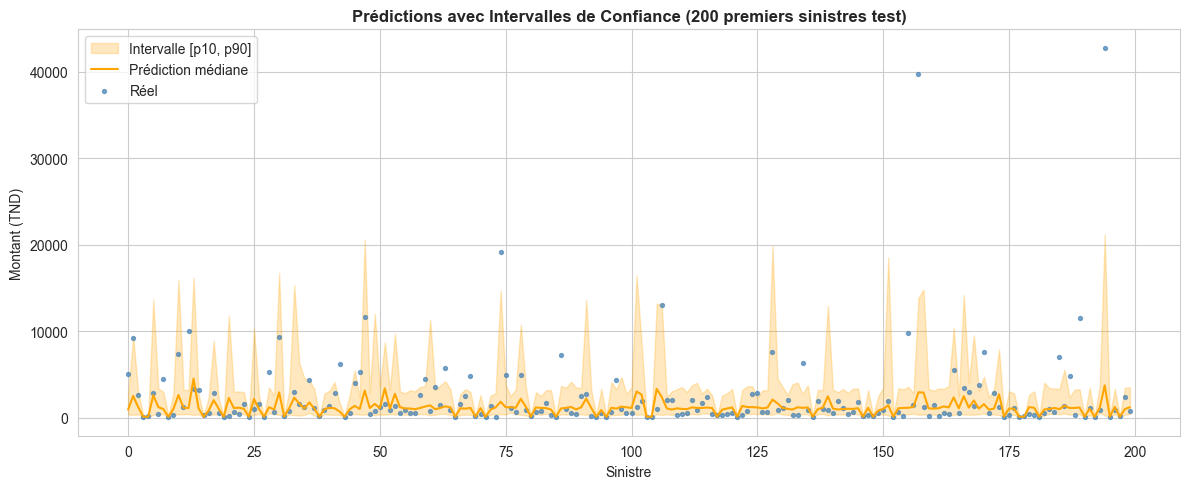

In [41]:
# Comparaison : provision naïve (médiane globale) vs provision ML (p90 prédit)
naive_provision   = df_model['MT_EVALUATION'].median()
ml_provision_p90  = df_test_results['PRED_P90']
reel              = df_test_results['MT_EVALUATION']

# Taux de sous-provisionnement
sous_naive = (naive_provision < reel).mean()
sous_ml    = (ml_provision_p90 < reel).mean()

# Excédent de provision (sur-réserve)
excedent_naive = np.maximum(naive_provision - reel, 0).sum()
excedent_ml    = np.maximum(ml_provision_p90 - reel, 0).sum()

print('=== Comparaison des Stratégies de Provisionnement ===')
print(f'\nProvision NAÏVE (médiane globale = {naive_provision:,.0f} TND pour tout sinistre)')
print(f'  Taux sous-provisionnement : {sous_naive*100:.1f}%')
print(f'  Excédent total            : {excedent_naive:,.0f} TND')

print(f'\nProvision ML (p90 personnalisé par sinistre)')
print(f'  Taux sous-provisionnement : {sous_ml*100:.1f}%')
print(f'  Excédent total            : {excedent_ml:,.0f} TND')

# Graphique
fig, ax = plt.subplots(figsize=(12, 5))
idx_plot = range(min(200, len(reel)))
reel_vals   = reel.values[:200]
pred_med    = df_test_results['PRED_MEDIAN'].values[:200]
pred_p10    = df_test_results['PRED_P10'].values[:200]
pred_p90    = df_test_results['PRED_P90'].values[:200]

ax.fill_between(idx_plot, pred_p10, pred_p90, alpha=0.25, color='orange', label='Intervalle [p10, p90]')
ax.plot(idx_plot, pred_med, color='orange', linewidth=1.5, label='Prédiction médiane')
ax.scatter(idx_plot, reel_vals, s=8, color='steelblue', alpha=0.7, label='Réel')
ax.set_title('Prédictions avec Intervalles de Confiance (200 premiers sinistres test)',
             fontweight='bold')
ax.set_xlabel('Sinistre'); ax.set_ylabel('Montant (TND)')
ax.legend()
plt.tight_layout(); plt.show()

## 15. Export

In [42]:
import pickle

# Sauvegarder les modèles
artifacts = {
    'xgb_model':       xgb_model,
    'lgb_model':       lgb_model,
    'quantile_models': quantile_models,
    'encoders':        encoders,
    'feature_cols':    FEATURE_COLS,
    'w_xgb':           w_xgb,
    'w_lgb':           w_lgb,
    'predict_fn':      predict_severity,
}
with open('claim_severity_model.pkl', 'wb') as f:
    pickle.dump(artifacts, f)
print('✅ Modèles sauvegardés : claim_severity_model.pkl')

✅ Modèles sauvegardés : claim_severity_model.pkl


---
## 16. 📋 Synthèse & Recommandations Métier

### Logique d'utilisation en production

```
Déclaration sinistre reçue
         │
         ▼
 Collecte des features
 (nature, véhicule, client, police)
         │
         ▼
  Modèle Ensemble
  ┌────────────────────────────────────┐
  │  Prédiction médiane   → Estimation │
  │  Prédiction p10       → Borne basse│
  │  Prédiction p90 + 5%  → PROVISION  │
  └────────────────────────────────────┘
         │
         ▼
   Niveau de sévérité
   🟢 Standard → Traitement normal
   🟠 Modéré   → Expertise standard
   🔴 Élevé    → Expertise prioritaire
                + Alerte réassurance
```

### Seuils de réassurance suggérés

| Nature | Seuil XL recommandé (p90) | Action |
|---|---|---|
| Incendie | ~25 000 TND | Alerte réassureur |
| Dégât des eaux | ~20 000 TND | Alerte réassureur |
| Vol | ~15 000 TND | Expertise externe |
| Corporel | ~10 000 TND | Médecin conseil |
| Matériel | ~5 000 TND | Traitement standard |
